In [2]:
import numpy as np
import pylab as plt 
import pandas as pd
from collections import Counter

In [22]:
# path to data files
df = pd.read_csv('../data/playlist_subset/playlist_subset_1.csv.gz', compression='gzip')

# Display the first 5 rows of the DataFrame
print(df.head())

   pos         artist_name                             track_uri  \
0    0       Nat King Cole  spotify:track:0yOLhQVpava7cJhVDbCvSh   
1    1         Josh Groban  spotify:track:0Znrkkl2NYC2AEbgEbENSO   
2    2        Idina Menzel  spotify:track:0Ie5uiv54KgCr7P4sYDTHl   
3    3  Anita Kerr Singers  spotify:track:4IdXngKo4g5exqZ0fQTecu   
4    4           Trap City  spotify:track:3HAYw27sjwSJNt9OuSJx55   

                              artist_uri  \
0  spotify:artist:7v4imS0moSyGdXyLgVTIV7   
1  spotify:artist:6cXMpsP9x0SH4kFfMyVezF   
2  spotify:artist:73Np75Wv2tju61Eo9Zw4IR   
3  spotify:artist:0vbEs3DgphJ2RGZqh4qFLT   
4  spotify:artist:78D8GHzW7QisjfTwhk9PM2   

                                          track_name  \
0                                     Deck The Halls   
1  Little Drummer Boy - featuring guitarist Andy ...   
2   Baby It's Cold Outside (duet with Michael Bublé)   
3                                   Jingle Bell Rock   
4                   The Nutcracker Christmas D

In [ ]:
# example of dataframe data necessary:
# name, tracks[track_uri]

#correlate songs:
#playlist title, song (starting with artist)

# DON'T USE THIS CODE

artist = df['artist_uri']
art_uri = []
for art in artist:
    if art not in artist:
        art_uri.append(art)
print((art_uri[0]))

spotify:artist:7v4imS0moSyGdXyLgVTIV7


In [1]:
artist = df['artist_uri']
art_uri = list(set(artist))
#seen_uri2 = list(set(track_uri))

print(len(art_uri))
#print(len(seen_uri), len(seen_uri2))

NameError: name 'df' is not defined

In [25]:
track_uri = df['track_uri']
seen_uri = []
for track in track_uri:
    if track not in seen_uri:
        seen_uri.append(track)

print(len(seen_uri))

111561


In [8]:
print(seen_uri[0])

spotify:track:0yOLhQVpava7cJhVDbCvSh


In [19]:
playlists = df['name']
seen_playlist = []
for title in playlists:
    if title not in seen_playlist:
        seen_playlist.append(title)
print(seen_playlist)

['Christmas music', 'SING', 'Play it Forward', 'Heavy Rotation', 'Sweet Dreams', 'bus', '80s', 'throwbacks ', 'Pump up', 'new', '<3', 'ACL 2015', 'ULTIMATE', 'Babe', 'tb ', 'dance', 'soccer', 'Throwback', 'mood', 'him', 'Go with the flow', 'car rides', 'Musica Italiana', 'Lauren', 'Driving', 'vibes', 'lift', 'random', 'my country', 'SAD DAYS', 'school playlist ', 'All my music', 'Carl', 'Da Best', 'Worship', 'The Very Best', 'running ', 'Sleepin', 'Christmas Vibes ', 'spin', 'Peanut Butter and jams!', 'Sugar', '2015', 'ROCK OUT', 'Kenny Rogers', 'Reception Dinner', 'Brave', 'Spencer :)', 'Yeah', 'Productivity', 'Sammy', 'Vroom', '2017', 'Sad', 'Dubstep', 'AM', 'ooouuu', 'Wedding', '( ͡° ͜ʖ ͡°  )', 'New', 'House', 'Spring 2017', ' jazz', 'favorite songs', 'sad', 'Best of the 90s', 'Studying', 'Reggae', 'Oldies', 'playlist 6', 'thanksgiving', 'Char', 'Alt', 'Daily playlist', 'tyga', 'Banger', 'Throwback ', 'Domingo', '90s Jams', 'Love songs', 'yolo', 'EDM', 'Study Music', 'Travis Scott',

In [10]:
#df['track_uri'][0]
print(len(df))
#print(seen_playlist[0], df['name'][0])
#current_playlist = df[(df['name']==seen_playlist[0])]
print(df['num_tracks'][0])

print(len(df)//5)

335357
5
67071


In [3]:
from nltk.corpus import wordnet as wn
wn.synonyms('christmas')

ModuleNotFoundError: No module named 'nltk'

In [101]:
#print(len(seen_playlist))
songs = []
list_songs = []
#list_playlists = []
num_songs = []
unique_artist = []
#full_count_artist = np.zeros(len(art_uri))
#print(len(full_count_artist))
#full_count_artist = np.array(full_count_artist)
z=268824 #0,67190,134185,201226,268365
while z<(335357):
    # get to current playlist
    current = []
    cur_art = []
    p_num = df['num_tracks'][z]
    num_songs.append(p_num)
    for x in range(p_num):
        current.append(df['track_uri'][z+x])
        cur_art.append(df['artist_uri'][z+x])

    # check if listed songs are in current playlist
    for y in range(len(seen_uri)):
        if seen_uri[y] in current:
            songs.append(1)    
        else:
            songs.append(0)
    list_songs.append(songs)
    songs = []

    # check how many unique artists are in playlists
    unique_art = list(set(cur_art))
    unique_art = len(unique_art)
    unique_artist.append(unique_art)

    # check how many times artists are in playlists
    count_artist = []
    counts = Counter(cur_art)
    for m in range(len(art_uri)):
        counts_art = counts[art_uri[m]]
        count_artist.append(counts_art)
    count_artist = np.array(count_artist)
    #print(np.sum(count_artist))
    full_count_artist = np.add(full_count_artist, count_artist)
    #print(np.sum(full_count_artist))

    #list_playlists.append(df['name'][z])
    z+=p_num
list_songs = np.array(list_songs)

#np.savetxt('data_files/playlist_set1.txt', list_songs)
np.savetxt('data_files/5playlist_set1_num.txt', num_songs)
#np.savetxt('data_files/1playlist_set1_artist_count_full1.txt', full_count_artist)
np.savetxt('data_files/5playlist_set1_artist_unique.txt', unique_artist)

#file_path = 'data_files/5playlist_set1_titles.txt'
#with open(file_path, "w") as file:
    #for item in list_playlists:
        #file.write(f"{item}\n")

In [122]:
print(unique_artist[1])
#print(num_songs)
print(full_count_artist[5])
print(z)
print(len(num_songs))

54
2.0
335357
997


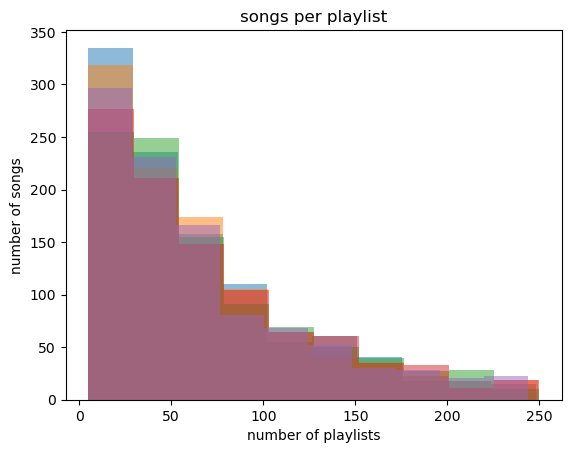

In [124]:
plt.title('songs per playlist')
plt.ylabel('number of songs')
plt.xlabel('number of playlists')

num_songs1 = np.loadtxt('data_files/1playlist_set1_num.txt')
num_songs2 = np.loadtxt('data_files/2playlist_set1_num.txt')
num_songs3 = np.loadtxt('data_files/3playlist_set1_num.txt')
num_songs4 = np.loadtxt('data_files/4playlist_set1_num.txt')
num_songs5 = np.loadtxt('data_files/5playlist_set1_num.txt')

plt.hist(num_songs1, alpha = 0.5)
plt.hist(num_songs2, alpha = 0.5)
plt.hist(num_songs3, alpha = 0.5)
plt.hist(num_songs4, alpha = 0.5)
plt.hist(num_songs5, alpha = 0.5)

plt.show()

In [123]:
print(len(num_songs1)+len(num_songs2)+len(num_songs3)+len(num_songs4)+len(num_songs5))

5000


In [ ]:
print(np.max(full_count_artist))

# Get indices of the top 10 maximum values
top_10_indices = sorted(range(len(full_count_artist)), key=lambda i: full_count_artist[i], reverse=True)[:10]

print("Indices of top 10 maximum values:", top_10_indices)

#np.savetxt('data_files/1playlist_set1_artist_count_FULL.txt', full_count_artist)


4270.0
Indices of top 10 maximum values: [19327, 23587, 1052, 4957, 17796, 22381, 1161, 9319, 10496, 1428]


In [113]:
#print(art_uri[0])
print(full_count_artist[1428])

print(df['artist_name'][df['artist_uri']==art_uri[1428]])
#print(df['artist_uri'][4])

1209.0
427       J. Cole
428       J. Cole
429       J. Cole
430       J. Cole
961       J. Cole
           ...   
332719    J. Cole
332736    J. Cole
332737    J. Cole
333799    J. Cole
334373    J. Cole
Name: artist_name, Length: 1209, dtype: object


In [1]:
# Data
categories = ['Drake', 'Kanye West', 'Kendrick Lamar', 'Rihanna', 'Ed Sheeran', 'The Weeknd', 'Justin Bieber', 'Future', 'Eminem', 'J. Cole']
values = [4270, 2290, 1611, 1493, 1315, 1307, 1290, 1215, 1211, 1209]

# Plot
plt.figure(figsize=(15, 5))
plt.bar(categories, values, color='skyblue')  # Bar plot for better visualization
plt.xlabel('Artists')
plt.ylabel('total songs seen')
plt.title('Most Popular Artists')
plt.show()

NameError: name 'plt' is not defined

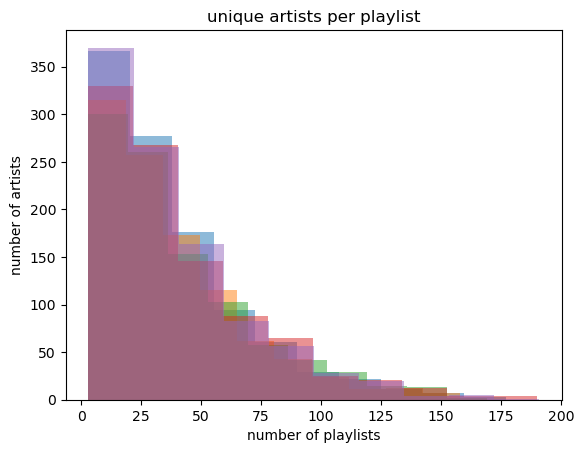

In [125]:
plt.title('unique artists per playlist')
plt.ylabel('number of artists')
plt.xlabel('number of playlists')

unique_artist1 = np.loadtxt('data_files/1playlist_set1_artist_unique.txt')
unique_artist2 = np.loadtxt('data_files/2playlist_set1_artist_unique.txt')
unique_artist3 = np.loadtxt('data_files/3playlist_set1_artist_unique.txt')
unique_artist4 = np.loadtxt('data_files/4playlist_set1_artist_unique.txt')
unique_artist5 = np.loadtxt('data_files/5playlist_set1_artist_unique.txt')

plt.hist(unique_artist1, alpha = 0.5)
plt.hist(unique_artist2, alpha = 0.5)
plt.hist(unique_artist3, alpha = 0.5)
plt.hist(unique_artist4, alpha = 0.5)
plt.hist(unique_artist5, alpha = 0.5)

plt.show()

In [18]:
np.average(unique_artist)
np.average(num_songs)

np.float64(64.17382999044891)

In [ ]:
# average amount of songs in each playlist //
# number of unique artists in each playlist //
# counter for how many times an artist shows up -- representation //

# associate top five/ten artists with genre
# coloring for number etc. to qualify data
# subset pcas for like-playlists


In [15]:
print(list_songs[0])
print(len(list_songs))

[1 1 1 ... 0 0 0]
1047


In [18]:
# Creating PCAs with the data:
outdir = 'pca/'
from sklearn.decomposition import PCA

pca = PCA(n_components=len(list_songs))
data = np.array(list_songs)
pca.fit(data.T)

np.savetxt(outdir + '1components.txt', pca.components_)
np.savetxt(outdir + '1explained_variance.txt', pca.explained_variance_)
np.save(outdir + '1pca_object.npy', pca)

In [19]:
pca = PCA(n_components=2)

S1 = list_songs[0]
S2 = list_songs[1]

data = np.array([S1,S2])
pca.fit(data.T)

#components of the PCA (the coefficients)
comp0 = pca.components_[0]
comp1 = pca.components_[1]

#The PCA maps 
PC0 = comp0[0]*S1+comp0[1]*S2
PC1 = comp1[0]*S1+comp1[1]*S2

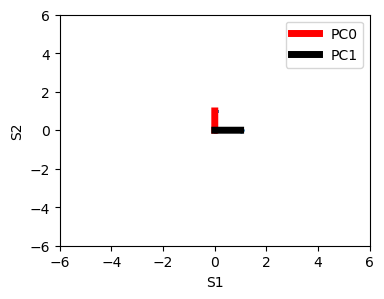

In [20]:

fig,ax = plt.subplots(1,1,sharey=True, figsize=(4,3))
ax.plot(S1,S2,'.')
ax.plot([0,comp0[0]],[0,comp0[1]], lw=5, color='r', label='PC0')
ax.plot([0,comp1[0]],[0,comp1[1]], lw=5, color='k', label='PC1')
ax.set_xlabel('S1'); ax.set_ylabel('S2'); ax.legend()
ax.set_xlim([-6,6]);ax.set_ylim([-6,6]);

In [ ]:
#UNUSED CODE
list_songs = []
number = 0
i=0
x=0
found = False
for w in range(1): #len(seen_playlist)
    current_playlist = df[df['name']== seen_playlist[i]]
    for y in range(len(seen_uri)):
        if any(current_playlist['track_uri'] == seen_uri[y]:
                list_songs.append(1)    
        else:
            list_songs.append(0)
    print(list_songs)
    #np.savetxt(number+'playlist.txt', list_songs)
    #number+=1
    #list_songs = []
    #i+=1

In [52]:
print(np.sum(list_songs))

65



        "name": "musical",
        "collaborative": "false",
        "pid": 5,
        "modified_at": 1493424000,
        "num_albums": 7,
        "num_tracks": 12,
        "num_followers": 1,
        "num_edits": 2,
        "duration_ms": 2657366,
        "num_artists": 6,
        "tracks": 
            {
                "pos": 0,
                "artist_name": "Degiheugi",
                "track_uri": "spotify:track:7vqa3sDmtEaVJ2gcvxtRID",
                "artist_uri": "spotify:artist:3V2paBXEoZIAhfZRJmo2jL",
                "track_name": "Finalement",
                "album_uri": "spotify:album:2KrRMJ9z7Xjoz1Az4O6UML",
                "duration_ms": 166264,
                "album_name": "Dancing Chords and Fireflies"
            }